In [12]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

import jax
from jax import vmap
import jax.numpy as jnp
import jax.random as random

import numpyro
from numpyro import handlers
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import time
import os
from sklearn.model_selection import train_test_split

Code from [NumPyro's Bayesian Neural Network example](https://num.pyro.ai/en/stable/examples/bnn.html)

No biases in the model

In [13]:
def model(X, Y, D_H, D_Y=1):
    N, D_X = X.shape

    # sample first layer (we put unit normal priors on all weights)
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
    assert w1.shape == (D_X, D_H)
    z1 = jnp.tanh(jnp.matmul(X, w1))  # <= first layer of activations
    # z1 = jax.nn.relu(jnp.matmul(X, w1))  # <= first layer of activations
    assert z1.shape == (N, D_H)

    # sample second layer
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
    assert w2.shape == (D_H, D_H)
    z2 = jax.nn.relu(jnp.matmul(z1, w2))  # <= second layer of activations
    # z2 = jnp.tanh(jnp.matmul(z1, w2))  # <= second layer of activations
    assert z2.shape == (N, D_H)

    # sample third layer
    w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
    assert w3.shape == (D_H, D_H)
    z3 = jax.nn.relu(jnp.matmul(z2, w3))  # <= second layer of activations
    # z3 = jnp.tanh(jnp.matmul(z2, w3))  # <= second layer of activations
    assert z3.shape == (N, D_H)

    # sample final layer of weights and neural network output
    w4 = numpyro.sample("w4", dist.Normal(jnp.zeros((D_H, D_Y)), jnp.ones((D_H, D_Y))))
    assert w4.shape == (D_H, D_Y)
    z4 = jnp.matmul(z3, w4)  # <= output of the neural network
    assert z4.shape == (N, D_Y)

    if Y is not None:
        assert z4.shape == Y.shape

    # we put a prior on the observation noise
    prec_obs = numpyro.sample("prec_obs", dist.Gamma(3.0, 1.0))
    sigma_obs = 1.0 / jnp.sqrt(prec_obs)

    # sigma_obs = 1.0  # runs slower than setting the observation noise to the two lines above...

    # observe data
    with numpyro.plate("data", N):
        # note we use to_event(1) because each observation has shape (1,)
        numpyro.sample("Y", dist.Normal(z4, sigma_obs).to_event(1), obs=Y)

def run_inference(model, args, rng_key, X, Y, D_H):
    start = time.time()
    kernel = NUTS(model)
    mcmc = MCMC(
        kernel,
        num_warmup=args["warmup"],
        num_samples=args["samples"],
        num_chains=args["chains"],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, X, Y, D_H)
    mcmc.print_summary()
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc.get_samples()


# helper function for prediction
def predict(model, rng_key, samples, X, D_H):
    model = handlers.substitute(handlers.seed(model, rng_key), samples)
    # note that Y will be sampled in the model because we pass Y=None here
    model_trace = handlers.trace(model).get_trace(X=X, Y=None, D_H=D_H)
    return model_trace["Y"]["value"]

In [14]:
from gpkanmodel.test_functions import trig
f = lambda x, y: trig(x, y) 

samples = 30
x_min, x_max = 0, 5

x1, x2 = jnp.meshgrid(jnp.linspace(x_min, x_max, samples), jnp.linspace(x_min , x_max, samples))
X = jnp.stack([x1.flatten(), x2.flatten()]).T
y = f(X[:, 0], X[:, 1]).reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
print(jnp.min(y), jnp.max(y))

4.0066595 6.05033


In [15]:
rng_key, rng_key_predict = random.split(random.PRNGKey(0))
n_samples = 2000
args = {"warmup": int(n_samples * 0.1),
        "samples": n_samples,
        "chains": 1,
        }
num_hidden = 32
# samples = run_inference(model, args, X=X, Y=y, D_H=num_hidden, rng_key=rng_key)
samples = run_inference(model, args, X=X_train, Y=y_train, D_H=num_hidden, rng_key=rng_key)

vmap_args = (
        samples,
        random.split(rng_key_predict, args["samples"] * args["chains"]),
    )

predictions_1 = vmap(
        lambda samples, rng_key: predict(model, rng_key, samples, X, num_hidden)
    )(*vmap_args)
predictions = predictions_1[..., 0]

mean_prediction = jnp.mean(predictions, axis=0)
percentiles = np.percentile(predictions, [5.0, 95.0], axis=0)

sample: 100%|██████████| 2200/2200 [06:44<00:00,  5.44it/s, 1023 steps of size 6.76e-04. acc. prob=0.58]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  prec_obs     26.37      2.88     26.77     22.77     30.39      8.13      1.32
   w1[0,0]      1.02      0.31      1.01      0.60      1.48      8.61      1.04
   w1[0,1]     -1.03      0.35     -1.08     -1.54     -0.43      5.33      1.22
   w1[0,2]      0.50      0.68      0.20     -0.03      1.87      6.04      1.18
   w1[0,3]     -0.15      0.09     -0.15     -0.30     -0.02      3.88      1.85
   w1[0,4]      0.31      0.17      0.29      0.03      0.58      6.84      1.00
   w1[0,5]      0.23      0.12      0.22      0.04      0.41     11.35      1.26
   w1[0,6]      0.89      0.18      0.87      0.64      1.22      9.65      1.19
   w1[0,7]     -0.51      0.27     -0.45     -0.97     -0.15      3.69      1.87
   w1[0,8]      0.63      1.05      0.12     -0.21      2.67      4.71      1.41
   w1[0,9]      0.93      0.37      0.96      0.36      1.51      6.31      1.11
  w1[0,10]      0.81      0

~8 mins runtime with [2, 32, 32, 1] BNN training on 900 total samples.

In [16]:
print(predictions.shape)

(2000, 900)


In [17]:
print(mean_prediction.shape)

print(jnp.min(mean_prediction), jnp.max(mean_prediction))

(900,)
-0.007774565 6.051845


In [18]:
def mse(y, yhat):
    return jnp.sum((y - yhat )**2) / y.shape[0]
mse(y.flatten(), mean_prediction.flatten()) 

Array(0.02343783, dtype=float32)

In [19]:
print(jnp.min(mean_prediction), jnp.max(mean_prediction))

-0.007774565 6.051845


In [20]:
# std_pred = jnp.var(predictions, axis=0)
# print(jnp.min(std_pred), jnp.max(std_pred))
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.contourf(x1, x2, std_pred.reshape(30, 30))
# ax.title()
# plt.show()

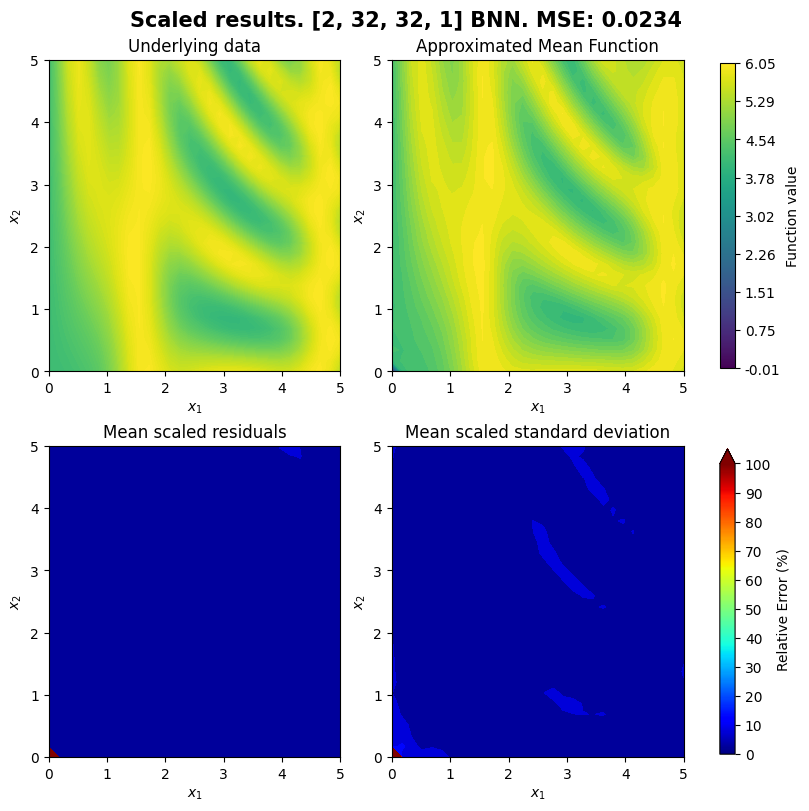

In [21]:
from plotting import plot_results_normalized, plot_results, plot_results_cv
res = y - mean_prediction.reshape(-1, 1)
fig, axs = plot_results_normalized(
    x1,
    x2,
    y=y,
    mu_hat=mean_prediction,
    sigma_hat=jnp.std(predictions, axis=0),
    title=f"Scaled results. [2, 32, 32, 1] BNN. MSE: {mse(y.flatten(), mean_prediction.flatten()):.4f}"
)
plt.savefig("result_plots/bnn_trig_scaled.png", dpi=100)
plt.show()

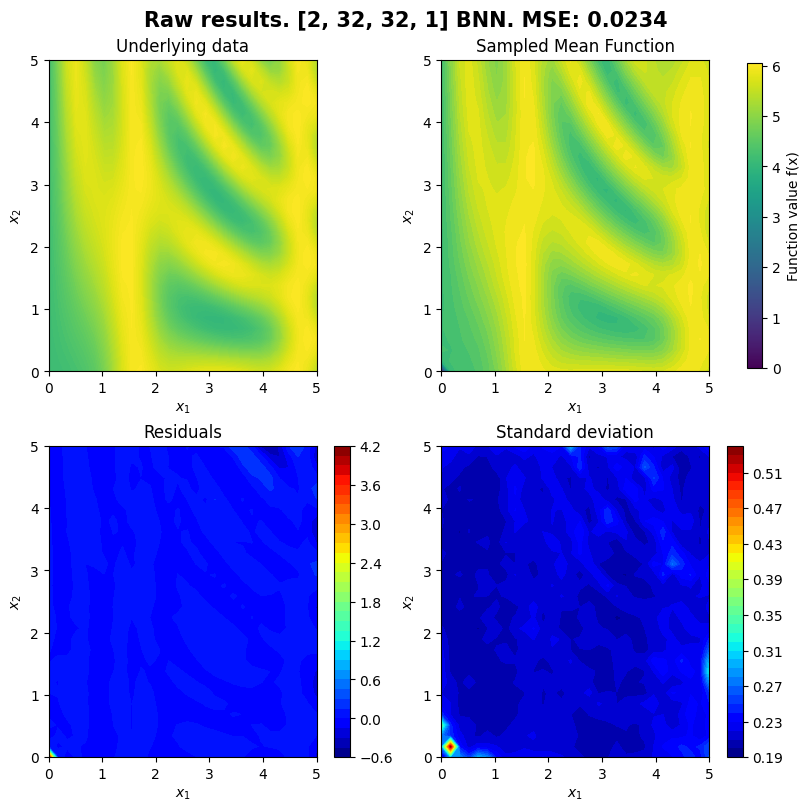

In [22]:
fig, axs = plot_results(
    x1,
    x2,
    y=y,
    mu_hat=mean_prediction,
    sigma_hat=jnp.std(predictions, axis=0),
    title=f"Raw results. [2, 32, 32, 1] BNN. MSE: {mse(y.flatten(), mean_prediction.flatten()):.4f}"
)
plt.savefig("result_plots/bnn_trig_raw.png", dpi=100)
plt.show()